In [174]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt

from datetime import timedelta, datetime, date

In [175]:
#Custom Yahoo Finance Get Data Fn
def GetYahooFinanceData(ticker, start, end):
    formatDate = "%Y-%m-%d"
    end = datetime.strptime(end, formatDate)
    end = end + timedelta(days = 1)
    end = end.strftime(formatDate)
    #this is to make sure the end date is included in the df

    df = yf.download(ticker, start, end)
    return df

stock_data = GetYahooFinanceData('NVDA','2022-01-01','2025-01-01')
stock_data

C:\Users\ashvi\AppData\Local\Temp\ipykernel_21100\1916507710.py:9: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start, end)
[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,NVDA,NVDA,NVDA,NVDA,NVDA
Date,,,,,
2022-01-03,30.062769,30.651628,29.727418,29.757361,391547000
2022-01-04,29.233374,30.409096,28.294193,30.218465,527154000
2022-01-05,27.550632,29.359130,27.479771,28.893031,498064000
2022-01-06,28.123524,28.383021,27.012676,27.586564,454186000
2022-01-07,27.194323,28.367052,27.004689,28.086595,409939000
...,...,...,...,...,...
2024-12-24,140.181656,141.861189,138.612078,139.961715,105157000
2024-12-26,139.891739,140.811501,137.692343,139.661806,116205600


In [176]:
#Calculate EMA12, EMA128, and EMA200 -> different lengths short to long term

stock_data['EMA12'] = stock_data['Close'].ewm(span=12, min_periods=0, adjust=False).mean()
stock_data['EMA50'] = stock_data['Close'].ewm(span=50, min_periods=0, adjust=False).mean()
stock_data['EMA128'] = stock_data['Close'].ewm(span=128, min_periods=0, adjust=False).mean()
stock_data['EMA200'] = stock_data['Close'].ewm(span=200, min_periods=0, adjust=False).mean()
#ewm is a pandas fn that calc the exponential weighted moving avg for a df (dataframe)
stock_data

Price,Close,High,Low,Open,Volume,EMA12,EMA50,EMA128,EMA200
Ticker,NVDA,NVDA,NVDA,NVDA,NVDA,,,,
Date,,,,,,,,,
2022-01-03,30.062769,30.651628,29.727418,29.757361,391547000,30.062769,30.062769,30.062769,30.062769
2022-01-04,29.233374,30.409096,28.294193,30.218465,527154000,29.935170,30.030244,30.049910,30.054516
2022-01-05,27.550632,29.359130,27.479771,28.893031,498064000,29.568318,29.933004,30.011162,30.029602
2022-01-06,28.123524,28.383021,27.012676,27.586564,454186000,29.346042,29.862044,29.981896,30.010636
2022-01-07,27.194323,28.367052,27.004689,28.086595,409939000,29.015008,29.757427,29.938678,29.982613
...,...,...,...,...,...,...,...,...,...
2024-12-24,140.181656,141.861189,138.612078,139.961715,105157000,136.189088,136.296354,126.175802,115.586663
2024-12-26,139.891739,140.811501,137.692343,139.661806,116205600,136.758727,136.437350,126.388452,115.828505


In [177]:
# Buy and Sell Signal Logic

stock_data['Buy_Signal'] = 0
stock_data['Sell_Signal'] = 0

for i in range(1, len(stock_data)):
    # golden cross -> buy signal [ema12 crosses above ema128]
    if (stock_data['EMA50'].iloc[i] > stock_data['EMA200'].iloc[i]) and (stock_data['EMA50'].iloc[i-1] <= stock_data['EMA200'].iloc[i-1]):
        stock_data.loc[stock_data.index[i], 'Buy_Signal'] = 1
    # death cross -> sell signal [ema12 crosses below ema128]
    elif (stock_data['EMA50'].iloc[i] < stock_data['EMA200'].iloc[i]) and (stock_data['EMA50'].iloc[i-1] >= stock_data['EMA200'].iloc[i-1]):
        stock_data.loc[stock_data.index[i], 'Sell_Signal'] = -1

stock_data

Price,Close,High,Low,Open,Volume,EMA12,EMA50,EMA128,EMA200,Buy_Signal,Sell_Signal
Ticker,NVDA,NVDA,NVDA,NVDA,NVDA,,,,,,
Date,,,,,,,,,,,
2022-01-03,30.062769,30.651628,29.727418,29.757361,391547000,30.062769,30.062769,30.062769,30.062769,0,0
2022-01-04,29.233374,30.409096,28.294193,30.218465,527154000,29.935170,30.030244,30.049910,30.054516,0,-1
2022-01-05,27.550632,29.359130,27.479771,28.893031,498064000,29.568318,29.933004,30.011162,30.029602,0,0
2022-01-06,28.123524,28.383021,27.012676,27.586564,454186000,29.346042,29.862044,29.981896,30.010636,0,0
2022-01-07,27.194323,28.367052,27.004689,28.086595,409939000,29.015008,29.757427,29.938678,29.982613,0,0
...,...,...,...,...,...,...,...,...,...,...,...
2024-12-24,140.181656,141.861189,138.612078,139.961715,105157000,136.189088,136.296354,126.175802,115.586663,0,0
2024-12-26,139.891739,140.811501,137.692343,139.661806,116205600,136.758727,136.437350,126.388452,115.828505,0,0


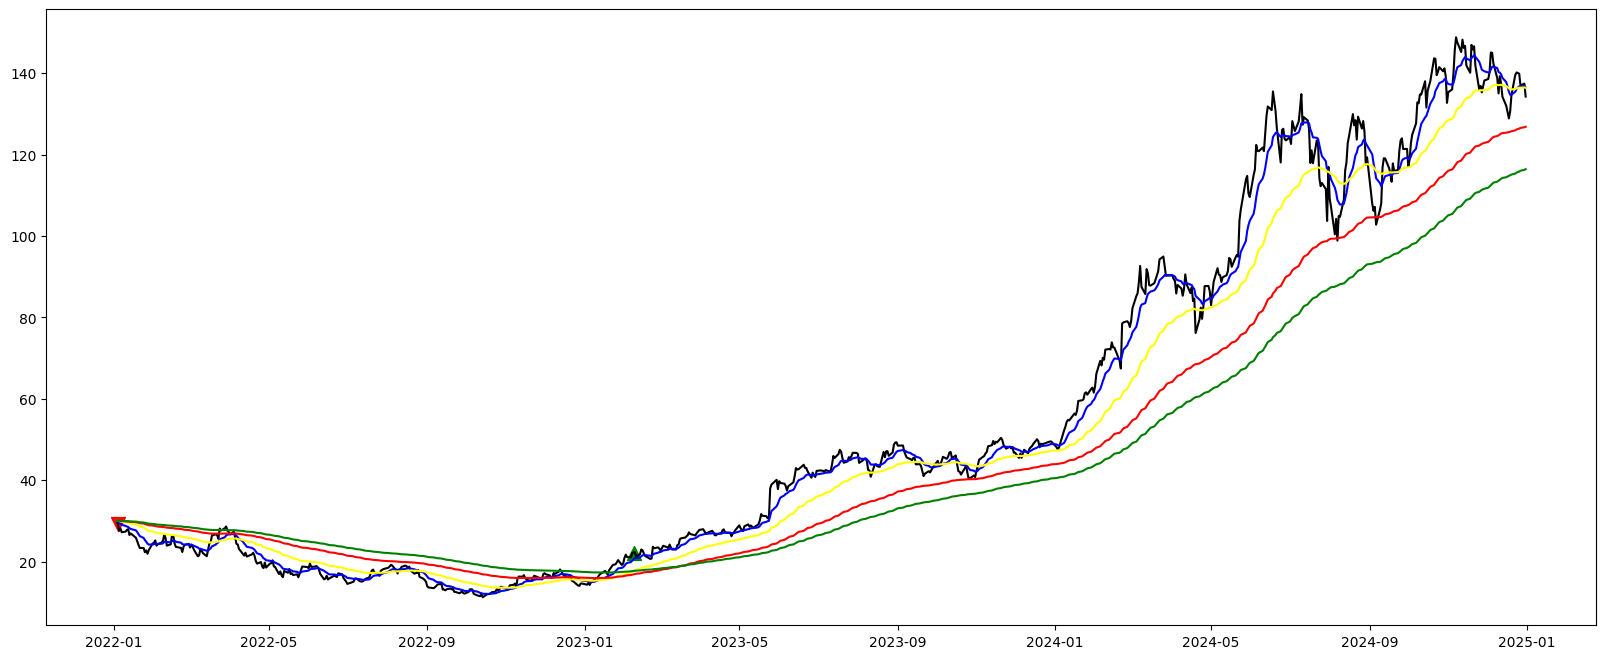

In [178]:
#Plot

plt.figure(figsize=(20,8))

plt.plot(stock_data.index, stock_data['Close'], label='Close Price', color = 'black')
plt.plot(stock_data.index, stock_data['EMA12'], label='EMA12', color = 'blue')
plt.plot(stock_data.index, stock_data['EMA50'], label='EMA50', color = 'yellow')
plt.plot(stock_data.index, stock_data['EMA128'], label='EMA128', color = 'red')
plt.plot(stock_data.index, stock_data['EMA200'], label='EMA200', color = 'green')

buy_signals = stock_data[stock_data['Buy_Signal'] == 1]
plt.scatter(buy_signals.index, buy_signals['Close'], marker="^", label = "Buy Signal", color = 'green', s = 100)

sell_signals = stock_data[stock_data['Sell_Signal'] == -1]
plt.scatter(sell_signals.index, sell_signals['Close'], marker="v", label = "Sell Signal", color = 'red', s = 100)



In [179]:
#Backtesting -> trading on historical data to assess profitability and risk

transaction_cost = 5

# Create arrays for equity tracking
algo_equity = []
bnh_equity = []

initial_capital = 100000
position = 0
capital = initial_capital
bought_and_held_capital = capital
bought_and_held_shares = (capital - transaction_cost) / stock_data['Close'].iloc[0]

for i in range(len(stock_data)):
    if stock_data['Buy_Signal'].iloc[i] == 1:
        shares_to_buy = capital // stock_data['Close'].iloc[i]
        position += shares_to_buy
        capital -= shares_to_buy * stock_data['Close'].iloc[i] + transaction_cost
    elif stock_data['Sell_Signal'].iloc[i] == -1:
        capital += position * stock_data['Close'].iloc[i] - transaction_cost
        position = 0
    
    bought_and_held_capital = bought_and_held_shares * stock_data["Close"].iloc[i]

    # Append to arrays instead of assigning to DataFrame
    algo_equity.append((capital + position * stock_data["Close"].iloc[i]).item())
    bnh_equity.append((bought_and_held_shares * stock_data["Close"].iloc[i]).item())

# Add to stock_data as new columns
stock_data['Algo_Equity'] = algo_equity
stock_data['BNH_Equity'] = bnh_equity

algorithm_final_value = capital + position * stock_data['Close'].iloc[-1]
bought_and_held_final_value = bought_and_held_capital

algorithm_final_percent = (algorithm_final_value - initial_capital)/initial_capital
bought_and_held_final_percent = (bought_and_held_final_value - initial_capital) / initial_capital

print("Algorithm final value: $", round(algorithm_final_value.item(), 2), "%: ", round(algorithm_final_percent.item()*100, 1))
print("Bought and held final value: $", round(bought_and_held_final_value.item(), 2), "%: ", round(bought_and_held_final_percent.item()*100, 1))
stock_data

Algorithm final value: $ 605091.68 %:  505.1
Bought and held final value: $ 446554.24 %:  346.6


Price,Close,High,Low,Open,Volume,EMA12,EMA50,EMA128,EMA200,Buy_Signal,Sell_Signal,Algo_Equity,BNH_Equity
Ticker,NVDA,NVDA,NVDA,NVDA,NVDA,,,,,,,,
Date,,,,,,,,,,,,,
2022-01-03,30.062769,30.651628,29.727418,29.757361,391547000,30.062769,30.062769,30.062769,30.062769,0,0,100000.000000,99995.000000
2022-01-04,29.233374,30.409096,28.294193,30.218465,527154000,29.935170,30.030244,30.049910,30.054516,0,-1,99995.000000,97236.259359
2022-01-05,27.550632,29.359130,27.479771,28.893031,498064000,29.568318,29.933004,30.011162,30.029602,0,0,99995.000000,91639.113495
2022-01-06,28.123524,28.383021,27.012676,27.586564,454186000,29.346042,29.862044,29.981896,30.010636,0,0,99995.000000,93544.668476
2022-01-07,27.194323,28.367052,27.004689,28.086595,409939000,29.015008,29.757427,29.938678,29.982613,0,0,99995.000000,90453.952953
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-12-24,140.181656,141.861189,138.612078,139.961715,105157000,136.189088,136.296354,126.175802,115.586663,0,0,631810.867937,466273.240162
2024-12-26,139.891739,140.811501,137.692343,139.661806,116205600,136.758727,136.437350,126.388452,115.828505,0,0,630504.212053,465308.916160


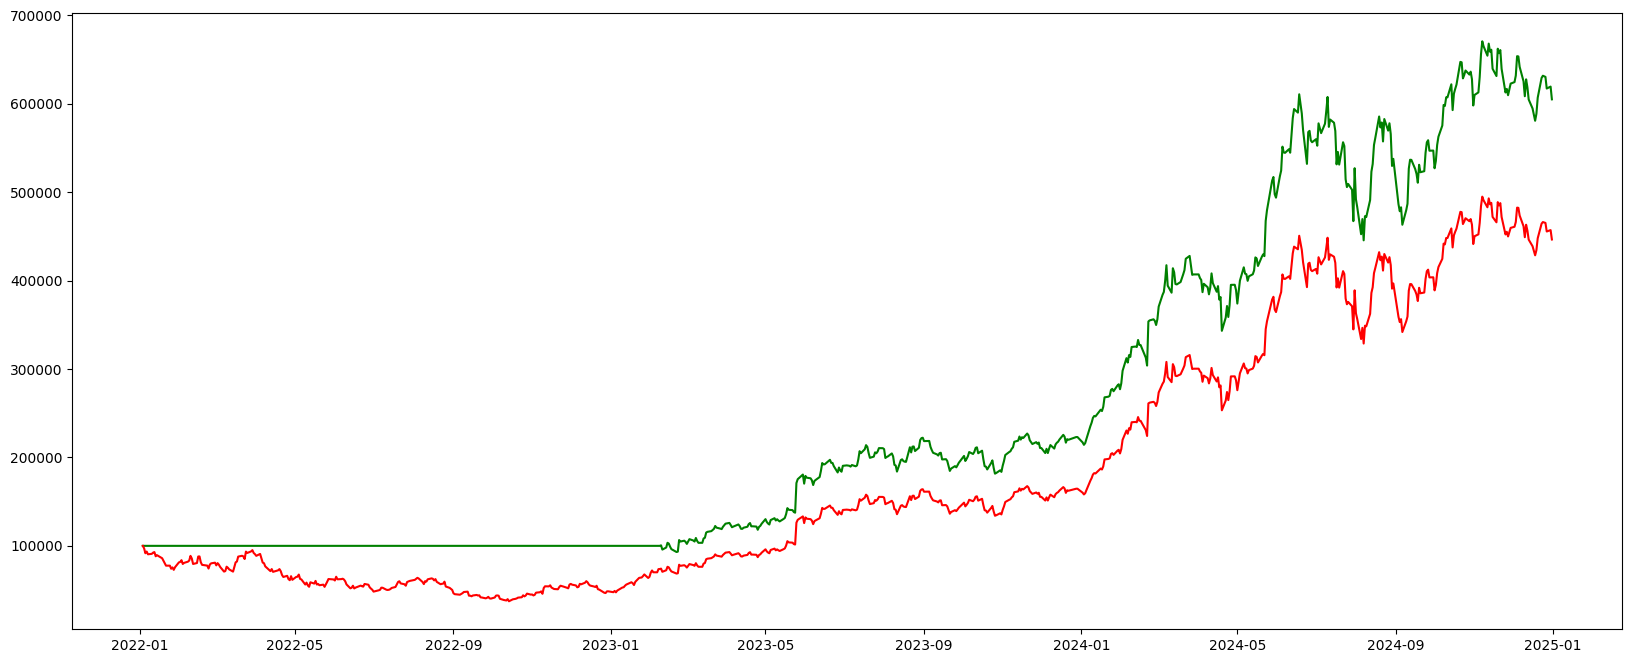

In [180]:
#Equity Curve Plot

plt.figure(figsize=(20,8))

plt.plot(stock_data.index, stock_data['Algo_Equity'], label = 'Algorithm Equity', color = 'green')
plt.plot(stock_data.index, stock_data['BNH_Equity'], label = 'Bought and Hold Equity', color = 'red')

In [181]:
#Risk metric -> max drawdown [largest decline to show volatility aka worst case scenario]

#finds peak from equity curve
#calculates mdd
#takes min -> most -ve % decrease

# Calculate Maximum Drawdown for Algorithm
algo_running_max = stock_data['Algo_Equity'].cummax()
algo_drawdown = (stock_data['Algo_Equity'] - algo_running_max) / algo_running_max
algo_max_drawdown = algo_drawdown.min()

# Calculate Maximum Drawdown for Buy and Hold
bnh_running_max = stock_data['BNH_Equity'].cummax()
bnh_drawdown = (stock_data['BNH_Equity'] - bnh_running_max) / bnh_running_max
bnh_max_drawdown = bnh_drawdown.min()

print("Algorithm Maximum Drawdown:", round(algo_max_drawdown * 100, 2), "%")
print("Buy and Hold Maximum Drawdown:", round(bnh_max_drawdown * 100, 2), "%")


Algorithm Maximum Drawdown: -27.05 %
Buy and Hold Maximum Drawdown: -62.7 %
